# Incoherent Camera Imaging — PSF and OTF Modes

Notebook version of `scripts/incoherent_camera_example.py`.  We model an **incoherent**
camera using `IncoherentImager` and compare two numerically equivalent implementations of
image formation:

1. **PSF mode** (spatial-domain convolution), and
2. **OTF mode** (frequency-domain multiplication).

This notebook also explains when the common convolution model is valid, including the
**paraxial approximation** and the shift-invariant (isoplanatic) assumption.

### Outline

0. **Imports** for optics components and numerics.
1. **Paths** for saved artifacts.
2. **Parameters** for the optical system and sensor.
3. **Helper functions** for the synthetic object and sensor ROI crop.
4. **Setup** of the optical system and incoherent imager (with equations).
5. **Evaluation** and summary metrics.
6. **Plot Results** for visual inspection.



## 0  Imports

We use `ThinLens` + `RSPropagator` to define the coherent point-response model, and then
wrap them in `IncoherentImager`, which converts that coherent response into an
**intensity-domain** imaging operator (PSF/OTF-based).


In [1]:
from __future__ import annotations

# NOTEBOOK_REPO_ROOT_SETUP
import os
from pathlib import Path as _Path
%matplotlib inline

def _find_repo_root(start: _Path) -> _Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "fouriax").exists()
            and (candidate / "README.md").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root from current working directory. "
        "Expected to find src/fouriax and README.md in an ancestor."
    )

REPO_ROOT = _find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters

The notebook resolves the repo root dynamically so plots and metrics are written to the
shared `artifacts/` directory regardless of where the notebook kernel starts.


In [2]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from fouriax.optics import (
    DetectorArray,
    Field,
    Grid,
    IncoherentImager,
    OpticalModule,
    RSPropagator,
    Spectrum,
    ThinLens,
)

ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "incoherent_camera.png"

WAVELENGTH_UM = 0.532
GRID_N = 192
GRID_DX_UM = 1.0
FOCAL_LENGTH_UM = 900.0
APERTURE_DIAMETER_UM = 90.0
SENSOR_SIZE_PX = 96
PLOT = True


## 2 Helper Functions

The synthetic object contains multiple spatial features (disk, ring, bars, Gaussian
envelope) so the resulting image exercises both low and high spatial frequencies.

Note that the object is created as an **intensity** map $I_{\mathrm{obj}}(x,y)$.  When constructing a
field for the simulation, the notebook uses amplitude $A = \sqrt{I_{\mathrm{obj}}}$ so that the field
intensity satisfies $|A|^2 = I_{\mathrm{obj}}$.


In [3]:
def _make_object_intensity(grid: Grid) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    r = jnp.sqrt(x * x + y * y)
    disk = (r <= 20.0).astype(jnp.float32)
    ring = ((r >= 32.0) & (r <= 40.0)).astype(jnp.float32)
    bars = (jnp.cos(2.0 * jnp.pi * x / 9.0) > 0.0).astype(jnp.float32)
    envelope = jnp.exp(-((r / 48.0) ** 2))
    return jnp.clip(0.05 + 0.45 * disk + 0.25 * ring + 0.25 * bars * envelope, 0.0, 1.0)


def _center_crop(image: np.ndarray, size_px: int) -> np.ndarray:
    ny, nx = image.shape
    y0 = (ny - size_px) // 2
    x0 = (nx - size_px) // 2
    return image[y0 : y0 + size_px, x0 : x0 + size_px]


## 3  Setup

### Incoherent imaging model (intensity linear system)

For spatially incoherent illumination, image formation is linear in **intensity** (not in
field amplitude).  Under the shift-invariant approximation, the image is

$$
I_{\mathrm{img}}(x,y) = (I_{\mathrm{obj}} * h_I)(x,y),
$$

where $h_I(x,y)$ is the **intensity PSF** (point-spread function), and `*` is 2D
convolution.

Equivalently in the spatial-frequency domain,

$$
\mathcal{F}\{I_{\mathrm{img}}\}(f_x,f_y)
= H_I(f_x,f_y)\,\mathcal{F}\{I_{\mathrm{obj}}\}(f_x,f_y),
$$

with

$$
H_I(f_x,f_y) = \mathcal{F}\{h_I\}(f_x,f_y),
$$

where $H_I$ is the **OTF** (optical transfer function).


### Paraxial approximation and when PSF convolution is valid

The convolution model above assumes the system is approximately **linear and
shift-invariant** over the field of view.  A standard route to this is the **paraxial
approximation**, where propagation angles are small enough that

$$
\sin\theta \approx \theta, \quad
\tan\theta \approx \theta, \quad
\cos\theta \approx 1 - \theta^2/2.
$$

In practice, PSF-convolution imaging is most accurate when:

- the lens is operated at modest NA (small angles),
- the image is formed near the intended focus plane,
- aberrations are limited, and
- the field of view is small enough that the PSF does not vary strongly with position.

Here the effective NA is

$$
\mathrm{NA} \approx \frac{D}{2f} = \frac{90}{2\cdot 900} = 0.05,
$$

which is comfortably paraxial, so the shift-invariant PSF/OTF model is a good working
approximation.


In [4]:
grid = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)

lens_na = APERTURE_DIAMETER_UM / (2.0 * FOCAL_LENGTH_UM)
sensor_width_um = SENSOR_SIZE_PX * grid.dx_um
hfov_deg = float(np.degrees(np.arctan((sensor_width_um * 0.5) / FOCAL_LENGTH_UM)))
fov_deg = 2.0 * hfov_deg

object_intensity = _make_object_intensity(grid)
field_in = Field.plane_wave(grid=grid, spectrum=spectrum).apply_amplitude(
    jnp.sqrt(object_intensity)[None, :, :]
)

lens = ThinLens(
    focal_length_um=FOCAL_LENGTH_UM,
    aperture_diameter_um=APERTURE_DIAMETER_UM,
)
rs = RSPropagator(
    use_sampling_planner=True,
    warn_on_regime_mismatch=False,
    medium_index=1.0,
    na_limit=lens_na,
)

imager_psf = IncoherentImager(
    optical_layer=lens,
    propagator=rs,
    distance_um=FOCAL_LENGTH_UM,
    psf_source="plane_wave_focus",
    normalize_psf=True,
    mode="psf",
)
imager_otf = IncoherentImager(
    optical_layer=lens,
    propagator=rs,
    distance_um=FOCAL_LENGTH_UM,
    psf_source="plane_wave_focus",
    normalize_psf=True,
    mode="otf",
)

detector_array = DetectorArray(
    detector_grid=grid,
    qe_curve=1.0,
)
module_psf = OpticalModule(layers=(imager_psf,), sensor=detector_array)
module_otf = OpticalModule(layers=(imager_otf,), sensor=detector_array)


## 4  Evaluation

We render the same object twice, once with `mode="psf"` and once with `mode="otf"`, then
measure mean-squared error between the two outputs on both the full grid and a central
sensor ROI crop.

Small parity error confirms that the two implementations of incoherent image formation are
consistent for this configuration.


In [5]:
image_psf = np.asarray(module_psf.measure(field_in))
image_otf = np.asarray(module_otf.measure(field_in))
crop_psf = _center_crop(image_psf, size_px=SENSOR_SIZE_PX)
crop_otf = _center_crop(image_otf, size_px=SENSOR_SIZE_PX)

parity_mse_full = float(np.mean((image_psf - image_otf) ** 2))
parity_mse_crop = float(np.mean((crop_psf - crop_otf) ** 2))
print("=== Incoherent Camera Example ===")
print(f"focal_length_um={FOCAL_LENGTH_UM:.1f}")
print(f"aperture_diameter_um={APERTURE_DIAMETER_UM:.1f}")
print(f"effective_na={lens_na:.4f}")
print(f"sensor_size_px={SENSOR_SIZE_PX} (from full grid {grid.nx}x{grid.ny})")
print(f"half_fov_deg={hfov_deg:.3f}, fov_deg={fov_deg:.3f}")
print(f"PSF/OTF parity MSE (full)={parity_mse_full:.3e}")
print(f"PSF/OTF parity MSE (crop)={parity_mse_crop:.3e}")


=== Incoherent Camera Example ===
focal_length_um=900.0
aperture_diameter_um=90.0
effective_na=0.0500
sensor_size_px=96 (from full grid 192x192)
half_fov_deg=3.053, fov_deg=6.106
PSF/OTF parity MSE (full)=8.151e-16
PSF/OTF parity MSE (crop)=1.912e-15


## 5 Plot Results

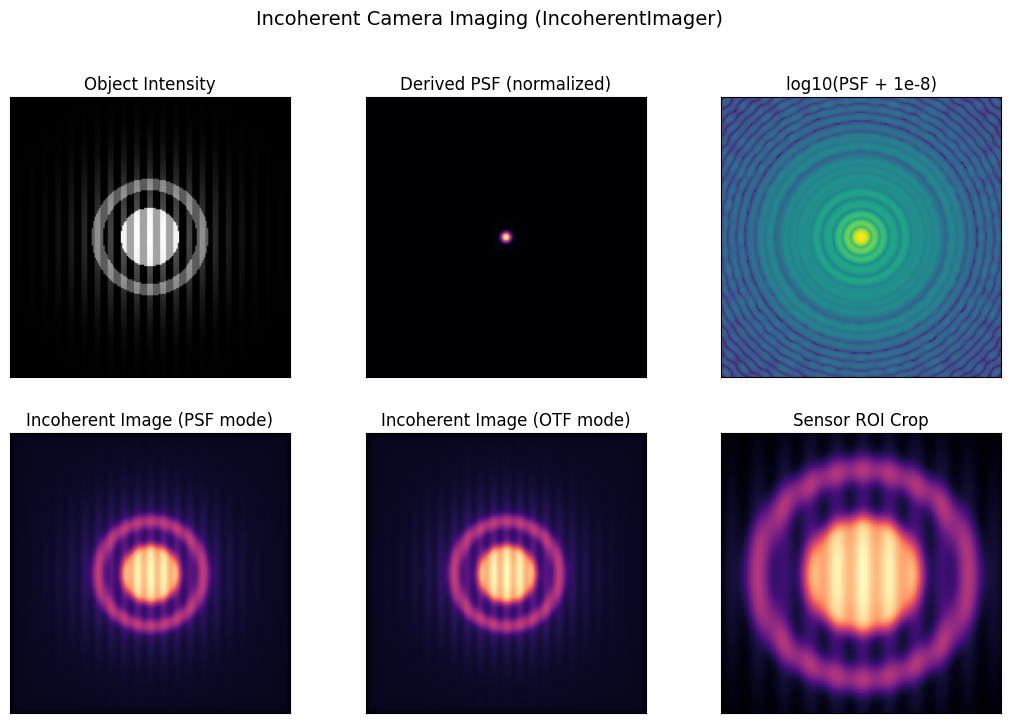

saved: artifacts/incoherent_camera.png


In [6]:
if PLOT:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    psf = np.asarray(imager_psf.build_psf(field_in))[0]
    psf = psf / (np.max(psf) + 1e-12)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    ax = axes.ravel()
    ax[0].imshow(np.asarray(object_intensity), cmap="gray")
    ax[0].set_title("Object Intensity")
    ax[1].imshow(psf, cmap="magma")
    ax[1].set_title("Derived PSF (normalized)")
    ax[2].imshow(np.log10(psf + 1e-8), cmap="viridis")
    ax[2].set_title("log10(PSF + 1e-8)")
    ax[3].imshow(image_psf, cmap="magma")
    ax[3].set_title("Incoherent Image (PSF mode)")
    ax[4].imshow(image_otf, cmap="magma")
    ax[4].set_title("Incoherent Image (OTF mode)")
    ax[5].imshow(crop_psf, cmap="magma")
    ax[5].set_title("Sensor ROI Crop")
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    fig.suptitle("Incoherent Camera Imaging (IncoherentImager)", fontsize=14, y=0.99)
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
